# **Distances Inter-Amino Acid**

## 📦 **Package Import**

In [1]:
# python
import pandas as pd
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path

# algorithms4pepprotgraphs framework
sys.path.append('/home/jovyan/work/algorithms4pepprotgraphs')
from algorithms4pepprotgraphs.module.notebook import NotebookApp
from algorithms4pepprotgraphs.util.plotting import boxplot, histogram

# init framework backend
app = NotebookApp('.env.jupyter.AVPDiscover.Ext')
paths = app.paths()

[2025-04-10 23:52:28,194] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/results_with_seq_2_to_100/AVP-external/Log/Sequences with Non-Natural Amino Acids.csv
[2025-04-10 23:52:45,171] INFO [notebook.py:70] Setting:
dataset_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/AVPDiscover/AVP-external.csv
pdb_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/AVPDiscover/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/results_with_seq_2_to_100/AVP-external
sequence_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/results_with_seq_2_to_100/AVP-external/2025-04-10T21.53.47-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/results_with_seq_2_to_100/AVP-external/2025-04-10T21.59.42-Graph_Analyzer
min_seq_len: None
max_seq_len: 100


## 📊 **Data Analysis**

### **Statistics of Inter-Amino Acid Distances**

In [2]:
statistics = pd.read_csv(app.sequence_analysis['sequence_inter_amino_acid_distances_summary'])
statistics

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,euclidean,21987540,7.322772e-01,19.966111,12.915140,11.083114,17.142416,25.354677,161.379453,1.793900,8.688431
1,canberra,21987540,2.060929e-02,1.046987,0.570485,0.604249,0.971370,1.406312,3.000000,0.649860,3.032348
2,lance_williams,21987540,8.134506e-03,0.327788,0.192084,0.180904,0.292713,0.440510,1.000000,0.833876,3.340458
3,clark,21987540,1.719209e-02,0.685063,0.347685,0.407634,0.652986,0.942622,1.732051,0.369038,2.459195
4,soergel,21987540,1.613774e-02,0.464245,0.206723,0.306382,0.452866,0.611603,1.000000,0.228614,2.371842
5,bhattacharyya,21987540,8.113768e-02,2.695552,1.553103,1.552723,2.409127,3.534445,16.225686,1.085435,4.632248
6,angular_separation,21987540,3.856711e-09,0.126330,0.153419,0.020398,0.068357,0.172790,1.000000,2.040081,7.719077


### **Analysis of the Distribution of Inter-Amino Acid Distances (*per Distance Function*)**

#### **Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*) 

<br>**Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*)<br>

<br>Statistics (*Euclidean, Bhattacharyya*)

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,euclidean,21987540,0.732277,19.966111,12.915140,11.083114,17.142416,25.354677,161.379453,1.793900,8.688431
1,bhattacharyya,21987540,0.081138,2.695552,1.553103,1.552723,2.409127,3.534445,16.225686,1.085435,4.632248


<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

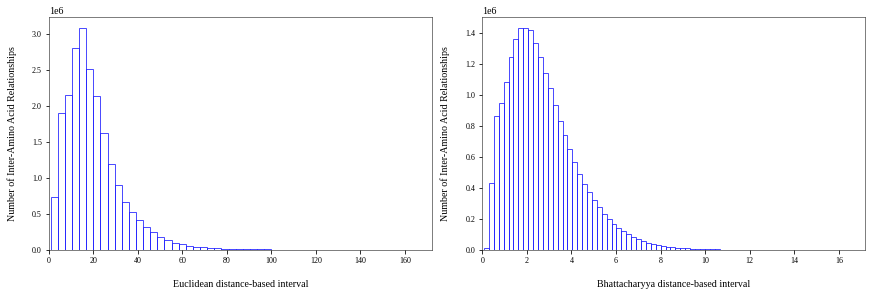

<br>Inter Amino Acid Distances (*Euclidean*)

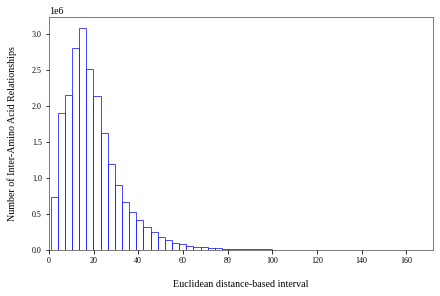

<br>Inter Amino Acid Distances (*Bhattacharyya*)

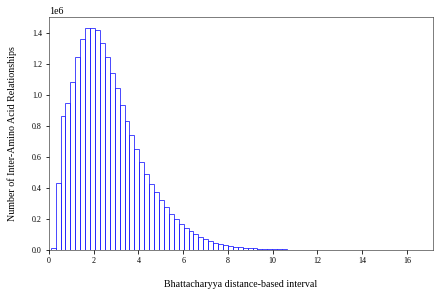

<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

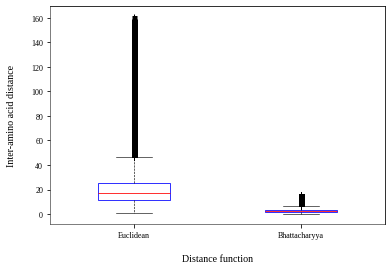

<br>Sequence with Largest Euclidean Distance: *MSYQQQQCKQPCQPPPVCPPKKCPEPCPHPQCPEPCPPPKCPEPCPEPCPPPSYQQKCPPVQPPPPCQQKCPPKSK*

Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

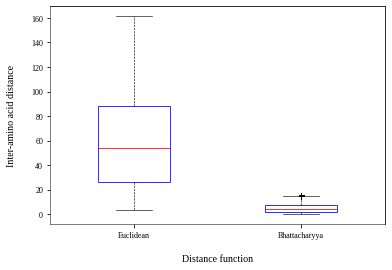

<br>Sequence with Largest Angular Separation Distance: *MPSHQHQNQQQCTPQAQQQQVKQPCQPPPTKCQEACVPKTKDPCVPQAKKQCPARSTTNPAQEKCPAQQDPKCKQK*

Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

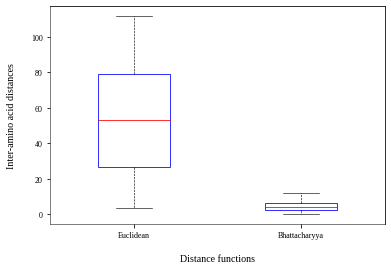

In [3]:
# distance functions 
distance_functions = ['euclidean', 'bhattacharyya']

# section name
display(Markdown("<br>**Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*)<br>"))

# statistics
display(Markdown("<br>Statistics (*Euclidean, Bhattacharyya*)"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histogram
distances = app.get_distance_values(distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Euclidean distance-based interval', 'Bhattacharyya distance-based interval']
bin_width = [3.2, 0.22]
x_axis_step = [20, 2]

display(Markdown("<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -histogram ")
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Euclidean*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu) -histogram")
plt = histogram(distances['euclidean'], x_labels[0], y_label, bin_width=bin_width[0], x_axis_step=x_axis_step[0], output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Bhattacharyya*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ba) -histogram")
plt = histogram(distances['bhattacharyya'], x_labels[1], y_label, bin_width=bin_width[1], x_axis_step=x_axis_step[1], output=output)
plt.show()
del distances, plt

# boxplot
distances = app.get_distance_values_and_pivot(distance_functions)
display(Markdown("<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance function'
y_label = 'Inter-amino acid distance'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -boxplot")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()
del distances, plt

# Sequence with Largest Euclidean Distance Value
result = app.get_sequences_with_largest_distance(distance_function='euclidean')
sequence = result['sequence'].item()
distances = app.get_distance_values_and_pivot(distance_functions, sequence)

display(Markdown(f"<br>Sequence with Largest Euclidean Distance: *{sequence}*"))
display(Markdown("Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))

x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance function'
y_label = 'Inter-amino acid distance'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -boxplot - (with_largest_eu_value)")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()
del distances, plt

# Sequence with Largest Angular Separation Distance Value
result = app.get_sequences_with_largest_distance(distance_function='angular_separation')
sequence = result['sequence'].item()
distances = app.get_distance_values_and_pivot(distance_functions, sequence)

display(Markdown(f"<br>Sequence with Largest Angular Separation Distance: *{sequence}*"))
display(Markdown("Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))

x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -boxplot - (with_largest_as_value)")
y_lim=(-1, 240)

plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)

<br>**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)<br>

<br>Statistics (*Canberra, Clark*)

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,canberra,21987540,0.020609,1.046987,0.570485,0.604249,0.971370,1.406312,3.000000,0.649860,3.032348
1,clark,21987540,0.017192,0.685063,0.347685,0.407634,0.652986,0.942622,1.732051,0.369038,2.459195


<br>Inter Amino Acid Distances (*Canberra, Clark*)

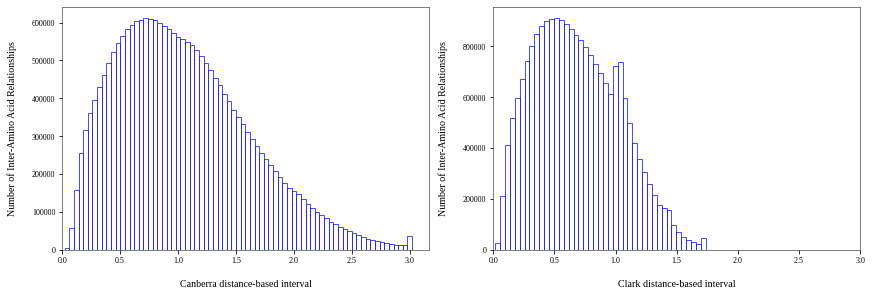

<br>Inter Amino Acid Distances (*Canberra*)

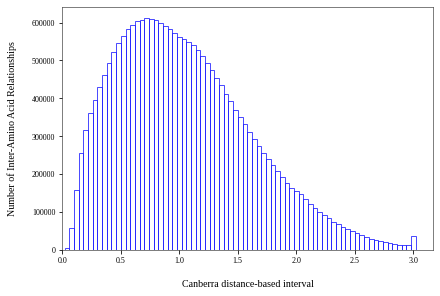

<br>Inter Amino Acid Distances (*Clark*)

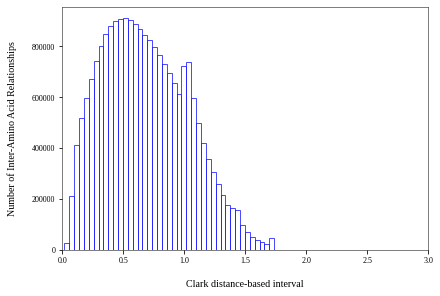

<br>Inter Amino Acid Distances (*Canberra, Clark*)

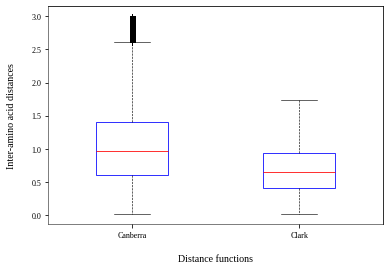

In [4]:
# distance functions
distance_functions = ['canberra', 'clark']

# section name
display(Markdown("<br>**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)<br>"))

# statistics
display(Markdown("<br>Statistics (*Canberra, Clark*)"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histograms
distances = app.get_distance_values(distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Canberra distance-based interval', 'Clark distance-based interval']
bin_width = 0.04
x_axis_step = 0.5

display(Markdown("<br>Inter Amino Acid Distances (*Canberra, Clark*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ca_cl) -histogram")
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Canberra*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ca) -histogram")
plt = histogram(distances['canberra'], x_labels[0], y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Clark*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (cl) -histogram")
plt = histogram(distances['clark'], x_labels[1], y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=output)
plt.show()

del distances, plt

# boxplot
distances = app.get_distance_values_and_pivot(distance_functions)

display(Markdown("<br>Inter Amino Acid Distances (*Canberra, Clark*)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Canberra', 'Clark']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ca_cl) -boxplot")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)

<br>**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)<br>

<br>Statistics (*Angular Separation, Lance Williams, Soergel*)

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,lance_williams,21987540,8.134506e-03,0.327788,0.192084,0.180904,0.292713,0.440510,1.0,0.833876,3.340458
1,soergel,21987540,1.613774e-02,0.464245,0.206723,0.306382,0.452866,0.611603,1.0,0.228614,2.371842
2,angular_separation,21987540,3.856711e-09,0.126330,0.153419,0.020398,0.068357,0.172790,1.0,2.040081,7.719077


<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)

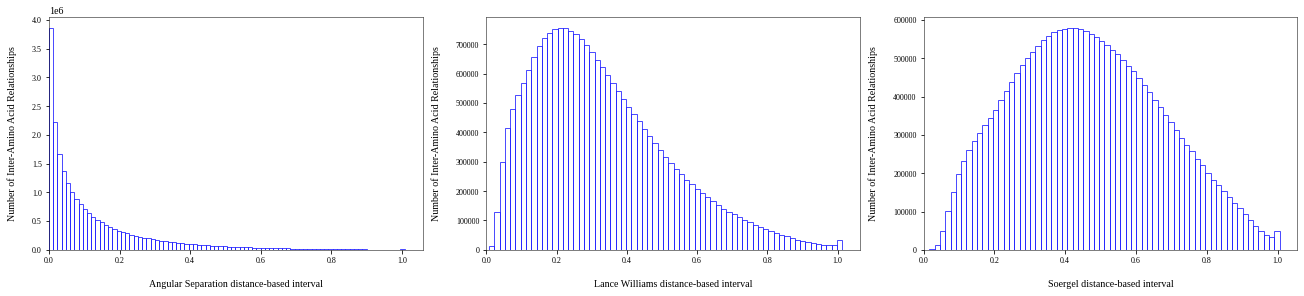

<br>Inter Amino Acid Distances (*Angular Separation)

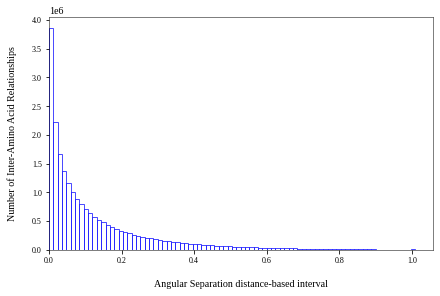

<br>Inter Amino Acid Distances (*Lance Williams*)

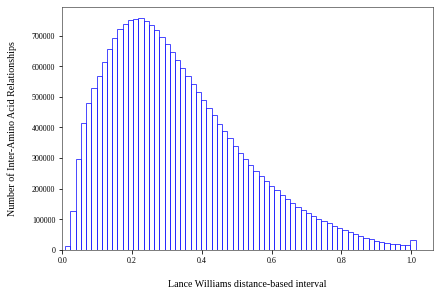

<br>Inter Amino Acid Distances (*Soergel*)

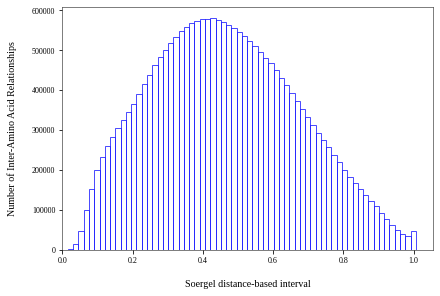

<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)

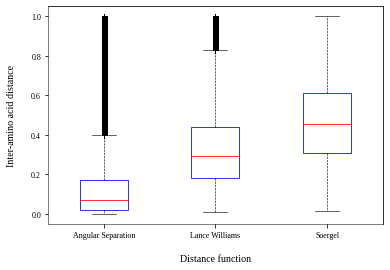

In [5]:
# distance_functions
distance_functions = ['angular_separation', 'lance_williams', 'soergel']

# section name
display(Markdown("<br>**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)<br>"))

# statistics
display(Markdown("<br>Statistics (*Angular Separation, Lance Williams, Soergel*)"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histograms
distances = app.get_distance_values(distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Angular Separation distance-based interval', 'Lance Williams distance-based interval', 'Soergel distance-based interval']
bin_width = [0.012, 0.015, 0.015]
x_axis_step = 0.2

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -histogram")
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=1, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as) -histogram")
plt = histogram(distances['angular_separation'], x_labels[0], y_label, bin_width[0], x_axis_step, x_axis_max=1, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Lance Williams*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (lw) -histogram")
plt = histogram(distances['lance_williams'], x_labels[1], y_label, bin_width[1], x_axis_step, x_axis_max=1, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Soergel*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (so) -histogram")
plt = histogram(distances['soergel'], x_labels[2], y_label, bin_width[2], x_axis_step, x_axis_max=1, output=output)
plt.show()

del distances, plt

# boxplot
distances = app.get_distance_values_and_pivot(distance_functions)

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks =['Angular Separation', 'Lance Williams', 'Soergel']
x_label = 'Distance function'
y_label = 'Inter-amino acid distance'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -boxplot")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)

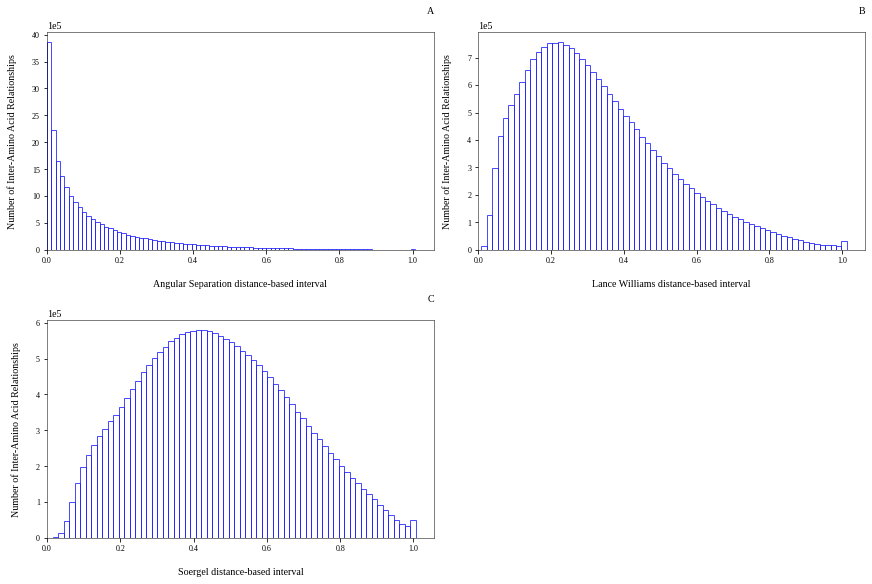

In [6]:
# distance_functions
distance_functions = ['angular_separation', 'lance_williams', 'soergel']

# histograms
distances = app.get_distance_values(distance_functions)

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)"))
y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Angular Separation distance-based interval', 'Lance Williams distance-based interval', 'Soergel distance-based interval']
bin_width = [0.012, 0.015, 0.015]
x_axis_step = 0.2
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -histogram_v)")
titles=['A', 'B', 'C']
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=1, output=output, titles=titles, n_cols=2, y_sci_limits=5, title_pad=18)
plt.show()

del distances, plt

In [ ]:
# Inter-amino acid Distance of the sequence 'ALWKNMLKGIGKLAGKAALGAVKKLVGAES'
distance_functions = ['angular_separation', 'lance_williams', 'soergel']
sequence = 'ALWKNMLKGIGKLAGKAALGAVKKLVGAES'
distances = app.get_distance_values_and_pivot(distance_functions, sequence)

display(Markdown("<br>Sequence: *ALWKNMLKGIGKLAGKAALGAVKKLVGAES*"))
display(Markdown("Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks =['Angular Separation', 'Lance Williams', 'Soergel']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -boxplot (sequence)")
y_lim=(-0.07, 1.07)

plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=y_lim, output=output, categories=distance_functions)
plt.show()

del distances, plt